# Week 3 — dataset, author fame, CLIP structure

**Exploration only — not on the reproducibility path** (see `notebooks/README.md`). Load-bearing
numbers live in `scripts/` + `build-log.md`.

| Section | Needs | Status |
|---|---|---|
| 1. What the English filter drops | `bbe_github.csv`, `books_english.parquet` | ready |
| 2. Author-fame proxies | `author_fame.parquet` | ready |
| 3. CLIP structure by genre | `clip_sample.npz` (4k) or `clip_embeddings.npz` (full) | ready on the 4k sample |
| 4. Full-N feature collinearity | `features_full.parquet` | **run `extract_features --books` first, then re-run this cell** |

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt

DATA = pathlib.Path('../data')
raw = pd.read_csv(DATA / 'bbe_github.csv', low_memory=False)
books = pd.read_parquet(DATA / 'books_english.parquet')
fame = pd.read_parquet(DATA / 'author_fame.parquet')
print(f'raw {len(raw):,}   english working set {len(books):,}')

raw 52,478   english working set 42,345


## 1. What the English filter drops

Question: is the ~19% we drop a random slice, or does it remove something systematic (a genre,
a rating band) that would bias the verdict toward 'English-language books' in a way worth stating?

dropped for non-English: 9,817
dropped for 0 ratings / no cover / dup (within English): 316


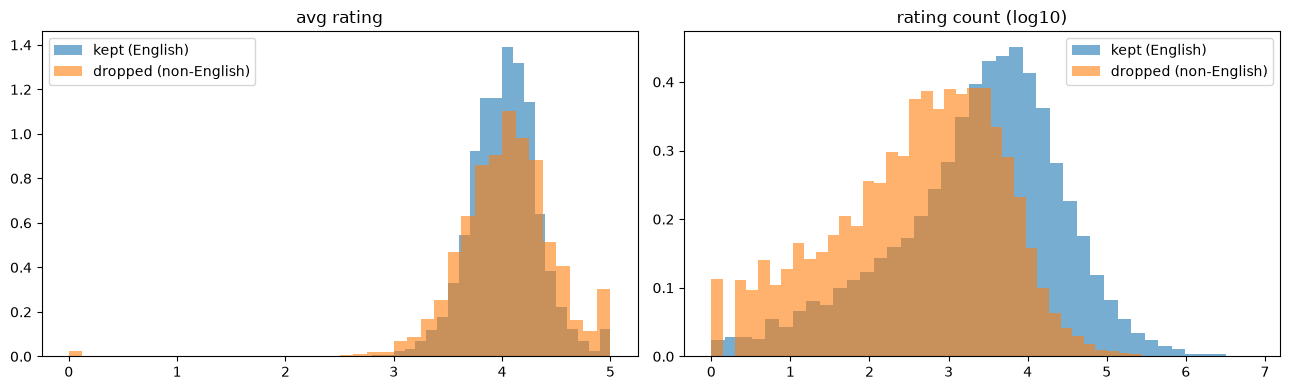

In [2]:
non_en = raw[raw['language'] != 'English']
print(f'dropped for non-English: {len(non_en):,}')
print(f'dropped for 0 ratings / no cover / dup (within English): {len(raw[raw.language=="English"]) - len(books):,}')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, col, lbl in [(ax[0], 'rating', 'avg rating'), (ax[1], 'numRatings', 'rating count (log10)')]:
    kept = books[col] if col == 'rating' else np.log10(books[col].clip(lower=1))
    drop = non_en[col].dropna() if col == 'rating' else np.log10(non_en[col].clip(lower=1).dropna())
    a.hist(kept, bins=40, density=True, alpha=0.6, label='kept (English)')
    a.hist(drop, bins=40, density=True, alpha=0.6, label='dropped (non-English)')
    a.set_title(lbl); a.legend()
fig.tight_layout()

In [3]:
def top_genre(g):
    import ast
    try:
        v = ast.literal_eval(g); return v[0] if isinstance(v, list) and v else None
    except Exception:
        return None

raw_g = raw['genres'].map(top_genre).value_counts(normalize=True)
kept_g = books['primary_genre'].value_counts(normalize=True)
cmp = pd.DataFrame({'raw_%': raw_g * 100, 'kept_%': kept_g * 100}).fillna(0)
cmp['shift_pp'] = cmp['kept_%'] - cmp['raw_%']
print('primary-genre mix, biggest shifts after filtering (percentage points):')
print(cmp.reindex(cmp['shift_pp'].abs().sort_values(ascending=False).index).head(12).round(2))

primary-genre mix, biggest shifts after filtering (percentage points):
                    raw_%  kept_%  shift_pp
Novels               0.83    0.05     -0.78
Young Adult          6.57    7.28      0.71
Fantasy             11.61   12.25      0.64
Mystery              4.06    4.58      0.52
Poetry               1.97    1.46     -0.52
Science Fiction      2.98    3.22      0.24
Historical Fiction   4.66    4.90      0.24
Fiction             12.83   12.60     -0.24
Short Stories        1.00    0.80     -0.19
Turkish Literature   0.19    0.00     -0.19
Paranormal           1.64    1.82      0.19
Religion             0.54    0.36     -0.18


## 2. Author-fame proxies

All leave-one-out. Checking: are they degenerate (everyone 0)? how heavy is the tail? and
**how strongly does each predict the two outcomes** — i.e. how much confounding is Model A
actually soaking up?

solo-author books: 0.287


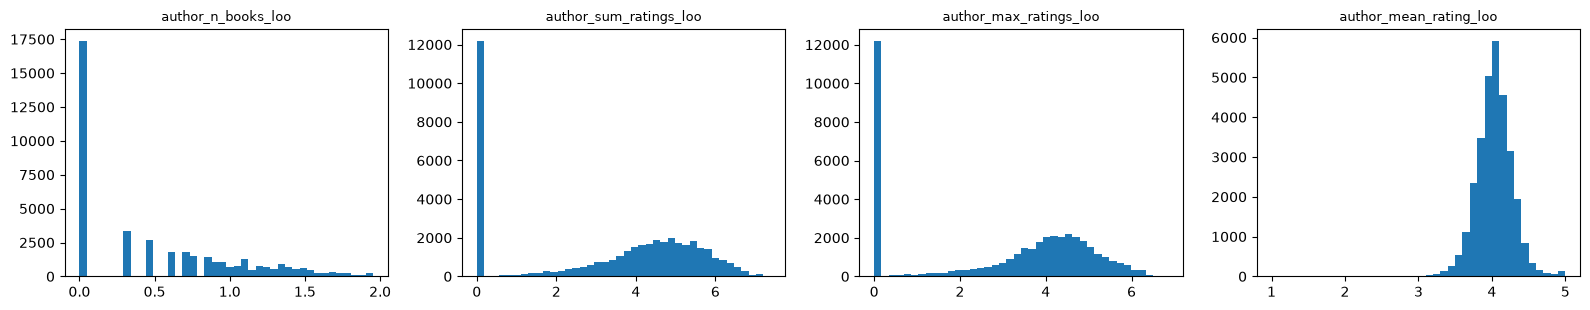

In [4]:
f = fame.join(books[['numRatings', 'rating', 'primary_genre']])
print('solo-author books:', f['author_is_solo'].mean().round(3))
cols = ['author_n_books_loo', 'author_sum_ratings_loo', 'author_max_ratings_loo', 'author_mean_rating_loo']
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, c in zip(axes, cols):
    v = f[c].dropna()
    v = np.log10(v.clip(lower=1)) if 'ratings' in c or c.endswith('books_loo') else v
    ax.hist(v, bins=40); ax.set_title(c, fontsize=9)
fig.tight_layout()

In [5]:
from scipy.stats import spearmanr
print('spearman(fame proxy, outcome) -- how much confound Model A removes:\n')
for c in cols:
    m = f[c].notna()
    rc = spearmanr(f.loc[m, c], f.loc[m, 'numRatings']).statistic
    rr = spearmanr(f.loc[m, c], f.loc[m, 'rating']).statistic
    print(f'  {c:24s}  vs numRatings {rc:+.3f}   vs rating {rr:+.3f}')

spearman(fame proxy, outcome) -- how much confound Model A removes:

  author_n_books_loo        vs numRatings +0.399   vs rating +0.095
  author_sum_ratings_loo    vs numRatings +0.574   vs rating +0.054
  author_max_ratings_loo    vs numRatings +0.581   vs rating +0.040
  author_mean_rating_loo    vs numRatings -0.047   vs rating +0.628


## 3. CLIP embedding structure by genre

Does a generic image embedding already separate genres? If covers cluster hard by genre, then
genre and 'what the cover looks like' are deeply entangled — which is exactly why Model B
(cover-only) will look predictive and Model C (controlled) is the real test.

Uses `clip_sample.npz` (4k) if present, else the full `clip_embeddings.npz`.

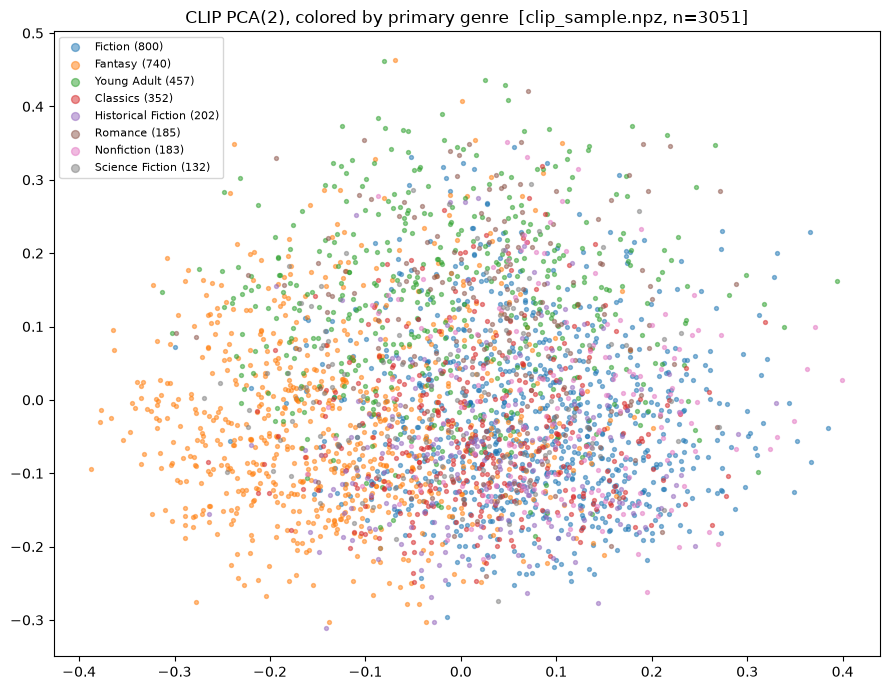

In [6]:
clip_path = DATA / 'clip_sample.npz' if (DATA / 'clip_sample.npz').exists() else DATA / 'clip_embeddings.npz'
z = np.load(clip_path, allow_pickle=True)
keys = [str(k) for k in z['keys']]; emb = z['embeddings']
g = books.reindex(keys)['primary_genre']
top = g.value_counts().head(8).index
mask = g.isin(top).to_numpy()

from sklearn.decomposition import PCA
xy = PCA(n_components=2, random_state=0).fit_transform(emb[mask])
gg = g[mask].to_numpy()
fig, ax = plt.subplots(figsize=(9, 7))
for genre in top:
    s = gg == genre
    ax.scatter(xy[s, 0], xy[s, 1], s=8, alpha=0.5, label=f'{genre} ({s.sum()})')
ax.legend(markerscale=2, fontsize=8); ax.set_title(f'CLIP PCA(2), colored by primary genre  [{clip_path.name}, n={mask.sum()}]')
fig.tight_layout()

In [7]:
# mean cosine similarity within a genre vs across genres (embeddings are L2-normed)
rows = []
for genre in top:
    idx = np.where(gg == genre)[0]
    if len(idx) < 10:
        continue
    e = emb[mask][idx]
    within = (e @ e.T)[np.triu_indices(len(idx), k=1)].mean()
    other = emb[mask][gg != genre]
    across = (e @ other.T).mean()
    rows.append((genre, len(idx), within, across, within - across))
print(pd.DataFrame(rows, columns=['genre', 'n', 'cos_within', 'cos_across', 'gap']).round(3).to_string(index=False))

             genre   n  cos_within  cos_across    gap
           Fiction 800       0.291       0.291  0.000
           Fantasy 740       0.366       0.307  0.058
       Young Adult 457       0.303       0.288  0.015
          Classics 352       0.339       0.299  0.039
Historical Fiction 202       0.326       0.305  0.021
           Romance 185       0.294       0.281  0.014
        Nonfiction 183       0.271       0.275 -0.004
   Science Fiction 132       0.309       0.292  0.017


## 4. Full-N feature collinearity  —  requires the full extraction run

The n=50 and n=500 collinearity numbers are in `build-log.md`. Model C's drop/regularize
decision should rest on the **full** parquet. Run:
```
python -m scripts.extract_features --books --out data/features_full.parquet
```
then re-run the cell below (or `python -m scripts.smoke_features_report --features data/features_full.parquet --no-sheet`).

n = 42,342
|spearman| > 0.6:
  sal_gini                   sal_top10_mass             +0.95
  sal_gini                   subband_entropy            -0.88
  sal_top10_mass             subband_entropy            -0.82
  n_text_detections          ocr_char_count             +0.79
  n_text_boxes_full          n_text_detections          +0.62
  median_text_contrast_ratio title_contrast_ratio       +0.78
  feature_congestion         sal_gini                   -0.74
  feature_congestion         sal_top10_mass             -0.79
  feature_congestion         subband_entropy            +0.73


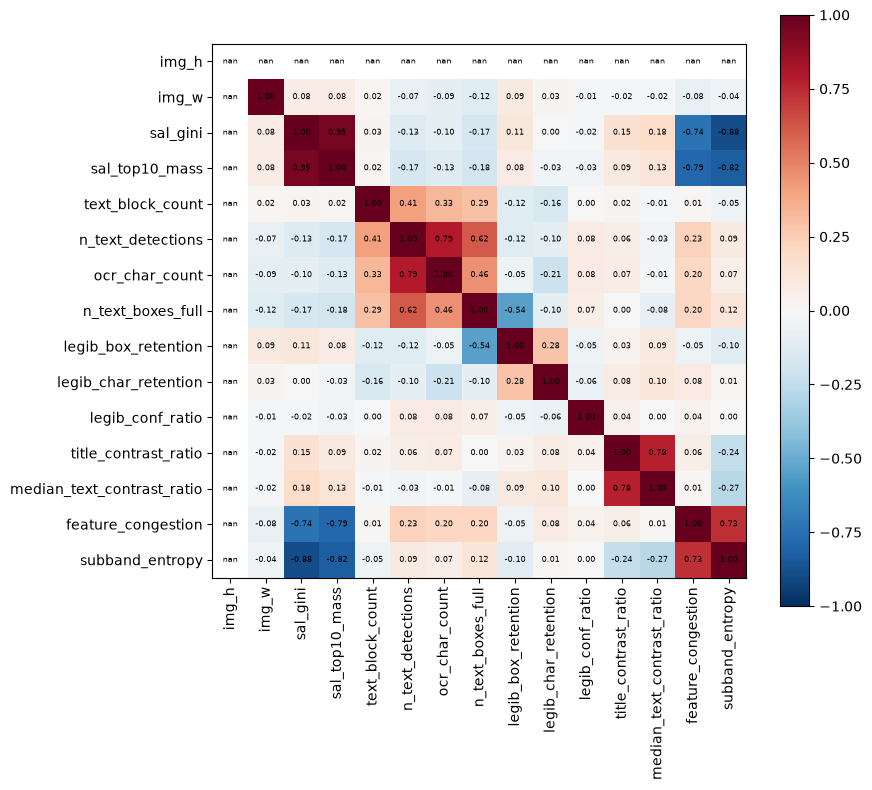

In [8]:
fp = DATA / 'features_full.parquet'
if not fp.exists():
    print('features_full.parquet not found — run extract_features --books first.')
else:
    feat = pd.read_parquet(fp).select_dtypes('number')
    corr = feat.corr('spearman')
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=6)
    fig.colorbar(im); fig.tight_layout()
    print(f'n = {len(feat):,}')
    print('|spearman| > 0.6:')
    for a in corr.columns:
        for b in corr.columns:
            if a < b and abs(corr.loc[a, b]) > 0.6:
                print(f'  {a:26s} {b:26s} {corr.loc[a, b]:+.2f}')